# Neural Network classification with pyTorch


## 1. Making Data


In [3]:
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import ipywidgets

In [4]:
# Make 1000 samples
n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
# Create circle
def cir_plot(noise):
  X, y = make_circles(n_samples,
                      noise=noise,
                      random_state=42)
  plt.style.use('dark_background')
  plt.scatter(x=X[:, 0],
              y=X[:, 1],
              c=y,
              cmap=plt.cm.RdYlBu)

In [5]:
ipywidgets.interact(cir_plot, noise=(0, 1, 0.01))

interactive(children=(FloatSlider(value=0.0, description='noise', max=1.0, step=0.01), Output()), _dom_classes…

<function __main__.cir_plot(noise)>

In [6]:
len(X), len(y)

(1000, 1000)

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
X[:3], y[:3]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203]]),
 array([1, 1, 1]))

In [9]:
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                          "Label": y})
circles.head()

,X1,X2,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


### 1.1 Check input and output shapes


In [10]:
X[:, :4]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [11]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f'Value for single sample of X: {X_sample}, and the same for y: {y_sample}')
print(f'Shape for single sample of X: {X_sample.shape}, and the same for y: {y_sample.shape}')

Value for single sample of X: [0.75424625 0.23148074], and the same for y: 1
Shape for single sample of X: (2,), and the same for y: ()


### 1.2 Turn data into tensor and create train and test splits


In [12]:
type(X)

numpy.ndarray

In [13]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:3], y[:3]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733]]),
 tensor([1., 1., 1.]))

In [14]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [15]:
# Split data into train and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)


In [16]:
len(X_train), len(X_test)

(800, 200)

## 2. Building a model


In [17]:
# Make device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [18]:
class CirclePredV0(nn.Module):
  def __init__(self):
    super().__init__()

    # Create nn layer capable of handling the shape of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    nn.ReLU()
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  # Define a forward layer
  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CirclePredV0().to(device)
model_0

CirclePredV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [19]:
next(model_0.parameters()).device

device(type='cpu')

In [20]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)


model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4232, -0.0798],
                      [-0.4444, -0.3139],
                      [ 0.2958,  0.0223],
                      [-0.6597, -0.6470],
                      [ 0.0971,  0.2814]])),
             ('0.bias', tensor([0.4525, 0.3328, 0.3087, 0.5652, 0.0452])),
             ('1.weight',
              tensor([[-0.1622, -0.4198,  0.1745,  0.3233,  0.1820]])),
             ('1.bias', tensor([0.2257]))])

In [22]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"length: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"preds is: \n{torch.round(untrained_preds[:10])} \nand ground true is: \n{y_test[:10]}")


length: 200, shape: torch.Size([200, 1])
preds is: 
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]) 
and ground true is: 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer


In [23]:
# Setup the loss function
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [24]:
# Calculate accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_true)) * 100
  return acc


## 3. Train model


### 3.1 Transfer the raw output into prediction label


In [25]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[0.2093],
        [0.2502],
        [0.1822],
        [0.2167],
        [0.3091]])

In [26]:
# Use the sigmoid activation function on our model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5521],
        [0.5622],
        [0.5454],
        [0.5540],
        [0.5767]])

In [27]:
# Find predicted labels
torch.round(y_pred_probs)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])

### 3.2 Building a train loop


In [28]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000


X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(0, epochs):
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate loss/accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  # Test
  if epoch % 10 == 0:
    model_0.eval()
    with torch.inference_mode():
      y_test_logits = model_0(X_test).squeeze()
      y_test_pred = torch.round(torch.sigmoid(y_test_logits))
      test_loss = loss_fn(y_test_pred, y_test)
      test_acc = accuracy_fn(y_test, y_test_pred)

    print(f"ep: {epoch:03} | loss: {loss:.3f} | acc: {acc:.2f}% | test loss: {test_loss:.3f} | test acc: {test_acc:.2f}%")

ep: 000 | loss: 0.702 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 010 | loss: 0.701 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 020 | loss: 0.700 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 030 | loss: 0.700 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 040 | loss: 0.699 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 050 | loss: 0.699 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 060 | loss: 0.698 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 070 | loss: 0.698 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 080 | loss: 0.697 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 090 | loss: 0.697 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 100 | loss: 0.697 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 110 | loss: 0.696 | acc: 50.00% | test loss: 0.813 | test acc: 50.00%
ep: 120 | loss: 0.696 | acc: 50.12% | test loss: 0.813 | test acc: 50.00%
ep: 130 | loss: 0.696 | acc: 53.50% | 

## 4. Make predictions and evaluate the model


In [29]:
import requests
from pathlib import Path

# Download helper function
if Path("helper_functions.py").is_file():
  print("helper_funcions.py already exists, skipping download")
else:
  print('Download helper_function.py')
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Download helper_function.py


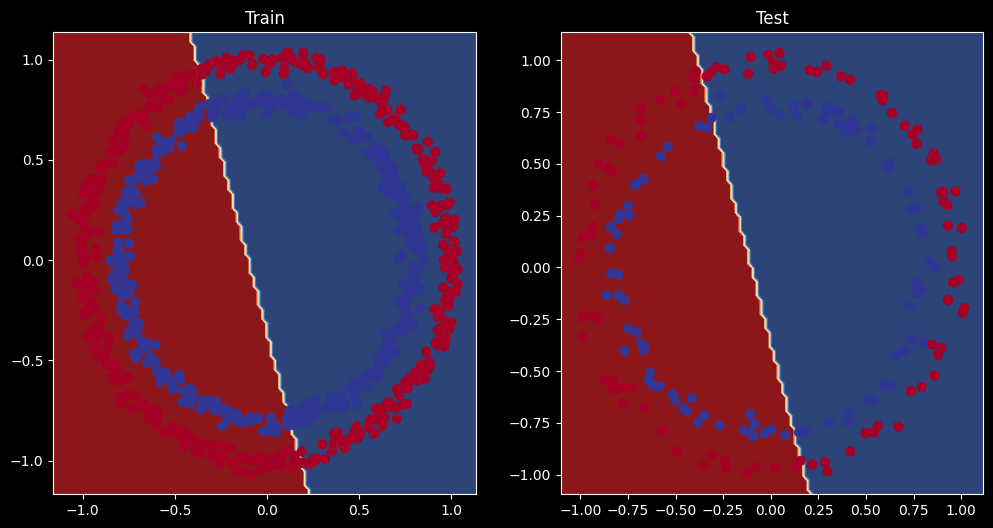

In [30]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test )

## 5. Improving a model (from a model perspective)


In [31]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
  def forward(self, x):
    z = self.layer_1(x)
    z = self.layer_2(z)
    z = self.layer_3(z)
    return z

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [32]:
# Setup a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [33]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(0, epochs):
  model_1.train()

  # forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss/acc
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step()
  optimizer.step()

  # Testing
  if epoch % 200 == 0:
    model_1.eval()
    with torch.inference_mode():
      test_logits = model_1(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))
      test_loss = loss_fn(test_logits,
                          test_logits)
      test_acc = accuracy_fn(y_test, test_pred)

    print(f"ep: {epoch:03} | loss: {loss:.3f} | acc: {acc:.3f} | test loss: {test_loss:.3f} | test acc: {test_acc:.3f}")

ep: 000 | loss: 0.694 | acc: 50.875 | test loss: 0.699 | test acc: 51.000
ep: 200 | loss: 0.694 | acc: 50.125 | test loss: 0.693 | test acc: 49.500
ep: 400 | loss: 0.693 | acc: 50.375 | test loss: 0.693 | test acc: 48.500
ep: 600 | loss: 0.693 | acc: 49.500 | test loss: 0.693 | test acc: 53.000
ep: 800 | loss: 0.693 | acc: 50.000 | test loss: 0.693 | test acc: 51.000


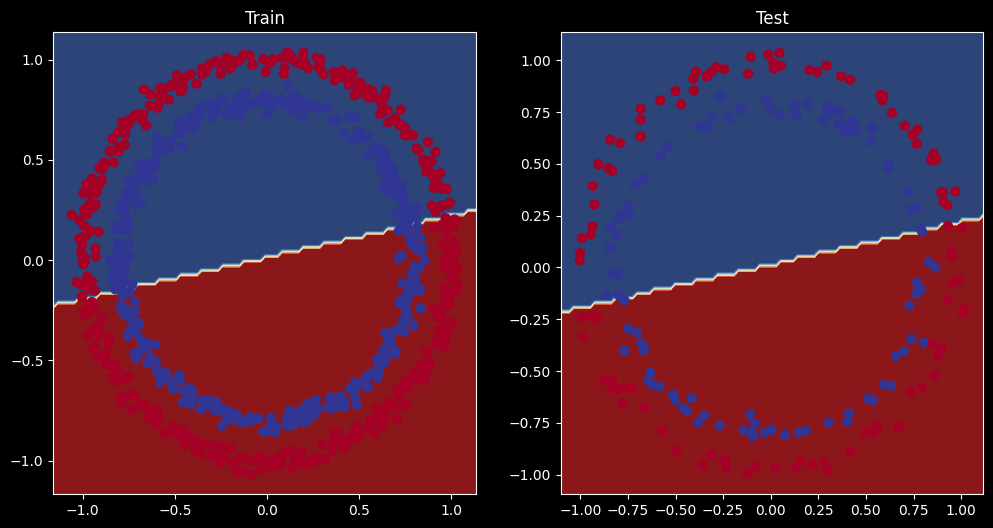

In [34]:
# Plot the decision boundry
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test )

In [35]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=-1)
y_regression = weight * X_regression + bias

In [36]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

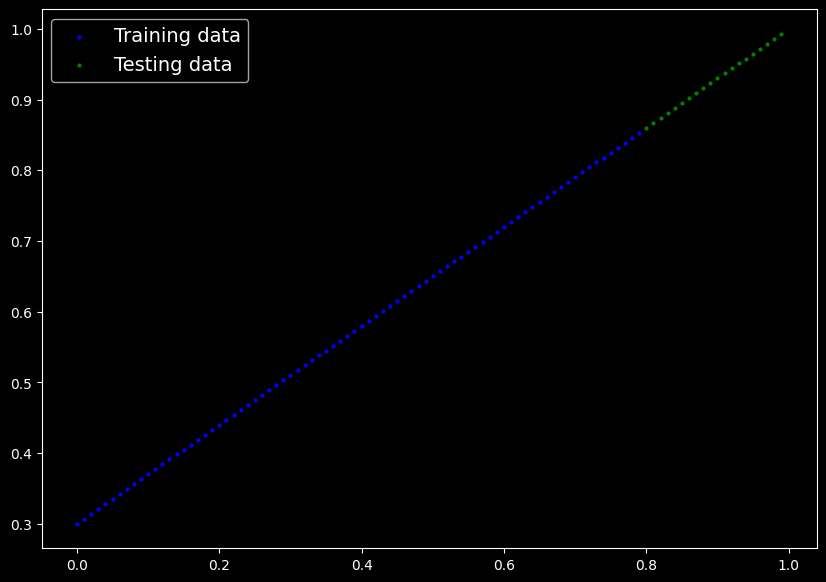

In [37]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

In [38]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [40]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    y_pred = model_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

    if epoch % 99 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}")

Epoch: 0 | Loss: 0.7599 | Test loss: 0.9110
Epoch: 99 | Loss: 0.0084 | Test loss: 0.0440
Epoch: 198 | Loss: 0.0251 | Test loss: 0.0018
Epoch: 297 | Loss: 0.0139 | Test loss: 0.0445
Epoch: 396 | Loss: 0.0202 | Test loss: 0.0040
Epoch: 495 | Loss: 0.0135 | Test loss: 0.0430
Epoch: 594 | Loss: 0.0194 | Test loss: 0.0039
Epoch: 693 | Loss: 0.0137 | Test loss: 0.0416
Epoch: 792 | Loss: 0.0184 | Test loss: 0.0037
Epoch: 891 | Loss: 0.0126 | Test loss: 0.0396
Epoch: 990 | Loss: 0.0176 | Test loss: 0.0033


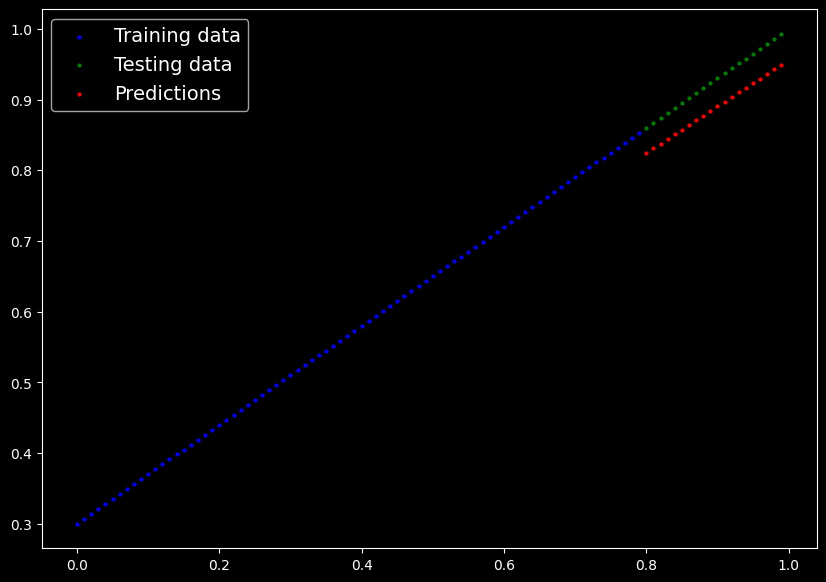

In [41]:
model_2.eval()

with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu()) 

## 6. The missing piece: non-linearity

### 6.1 Recreating non-linear data (red and blue circle)

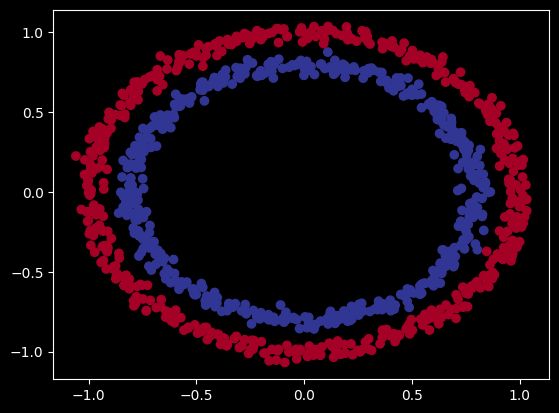

In [42]:
n_samples =  1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [43]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

In [44]:
# Build a model with non-linear activation function

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [45]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.1)

### 6.3 Training a model with non-linearity

In [46]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6929, Acc: 50.00% | Test Loss: 0.6932, Test Acc: 50.00%
Epoch: 100 | Loss: 0.6912, Acc: 52.88% | Test Loss: 0.6910, Test Acc: 52.50%
Epoch: 200 | Loss: 0.6898, Acc: 53.37% | Test Loss: 0.6894, Test Acc: 55.00%
Epoch: 300 | Loss: 0.6879, Acc: 53.00% | Test Loss: 0.6872, Test Acc: 56.00%
Epoch: 400 | Loss: 0.6852, Acc: 52.75% | Test Loss: 0.6841, Test Acc: 56.50%
Epoch: 500 | Loss: 0.6810, Acc: 52.75% | Test Loss: 0.6794, Test Acc: 56.50%
Epoch: 600 | Loss: 0.6751, Acc: 54.50% | Test Loss: 0.6729, Test Acc: 56.00%
Epoch: 700 | Loss: 0.6666, Acc: 58.38% | Test Loss: 0.6632, Test Acc: 59.00%
Epoch: 800 | Loss: 0.6516, Acc: 64.00% | Test Loss: 0.6476, Test Acc: 67.50%
Epoch: 900 | Loss: 0.6236, Acc: 74.00% | Test Loss: 0.6215, Test Acc: 79.00%


### 6.4 Evaluating a mdel trained with non-linear activation function

In [47]:
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

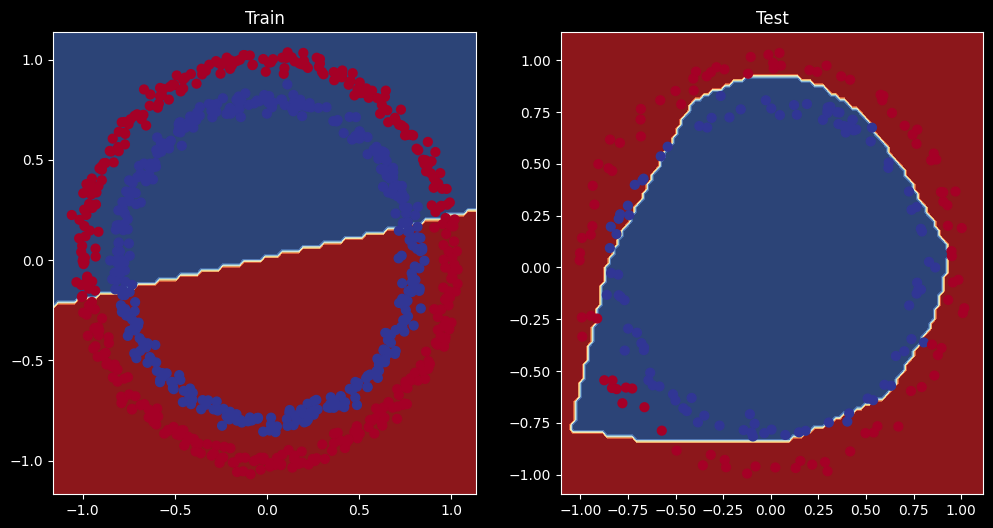

In [48]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

## 7. Replicating non-linear activation functions

In [49]:
# Create a tensor
A = torch.arange(-10, 10, 1)
A.dtype

torch.int64

In [50]:
A

tensor([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,
          4,   5,   6,   7,   8,   9])

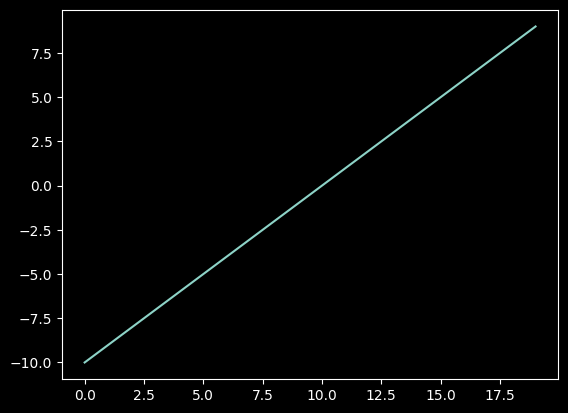

In [51]:
# Visualize the tensor
plt.plot(A)

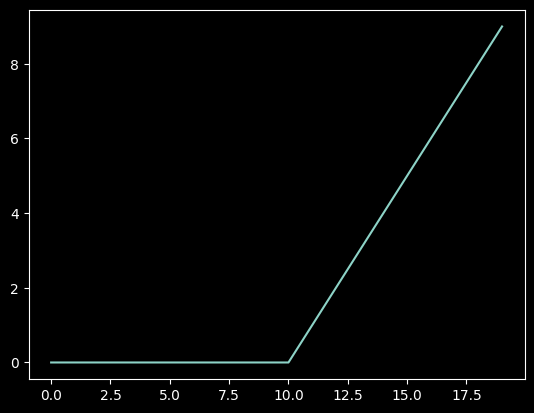

In [52]:
plt.plot(torch.relu(A))

In [53]:
def relu(X: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), X)

relu(A)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

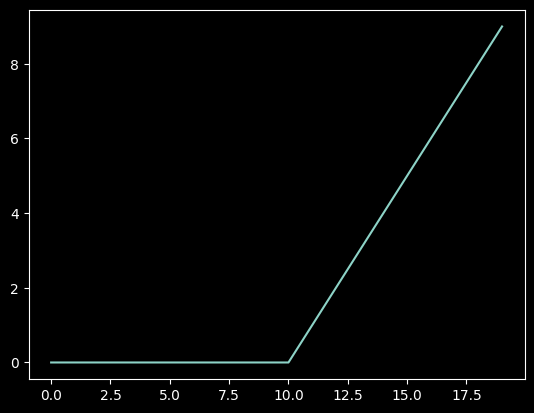

In [54]:
# Plot ReLU activation function
plt.plot(relu(A))

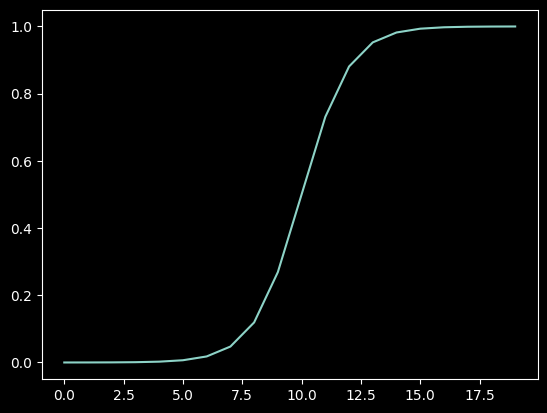

In [55]:
plt.plot(torch.sigmoid(A))

In [56]:
def sigmoid(X):
    return 1/ (1 + torch.exp(-X))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

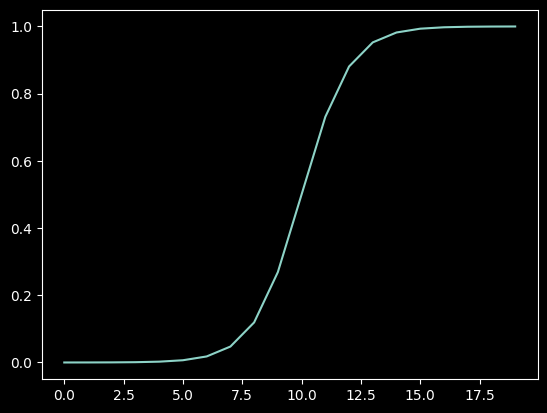

In [57]:
plt.plot(sigmoid(A))

## 8. Putting it all together with a multi-class classification problem

### 8.1 Creating a toy multi-class dataset

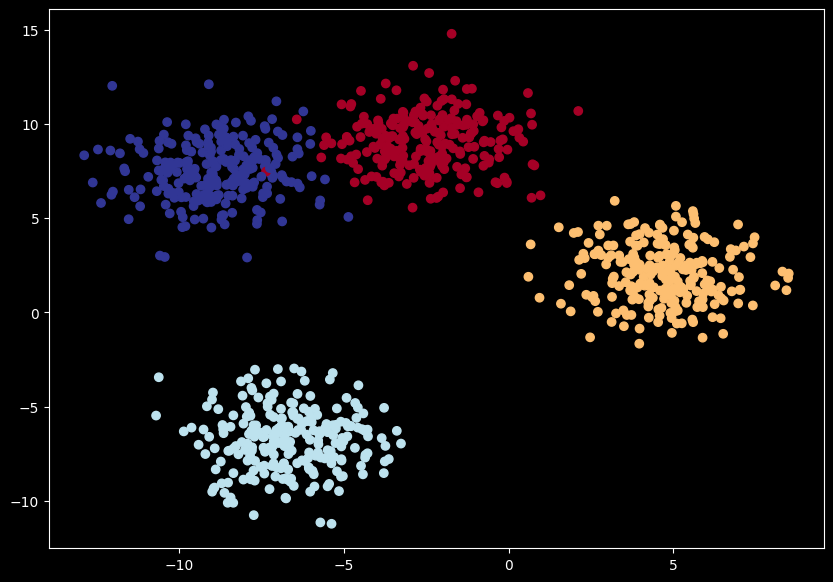

In [58]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu) 

### 8.2 Building a multi-class classification in PyTorch

In [59]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [60]:
# Building a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes multi-class classification model."""
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
#            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
#            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )

    def forward(self, X):
        return self.linear_layer_stack(X)

model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [61]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [62]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

### 8.3 Create a loss function and an optimizer for a multi-class classification model

In [63]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

In [64]:
model_4.eval()
with torch.inference_mode():    
   y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]])

In [65]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]])


In [66]:
torch.argmax(y_pred_probs[0])

tensor(3)

In [67]:
torch.max(y_pred_probs[0])

tensor(0.3715)

In [68]:
# Convert our model's prediction probabilities to prediction labels
y_pred = torch.argmax(y_pred_probs, dim=1)
y_pred

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3])

### 8.5 Creating a training loop and testing loop for a multi-class PyTorch model

In [69]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing 
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test,
                               y_pred=test_preds)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}% | Acc: {acc:.2f} |Test Loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%")
        

Epoch: 0 | Loss: 1.0432% | Acc: 65.50 |Test Loss: 0.5786 | Test acc: 95.50%
Epoch: 10 | Loss: 0.1440% | Acc: 99.12 |Test Loss: 0.1304 | Test acc: 99.00%
Epoch: 20 | Loss: 0.0806% | Acc: 99.12 |Test Loss: 0.0722 | Test acc: 99.50%
Epoch: 30 | Loss: 0.0592% | Acc: 99.12 |Test Loss: 0.0513 | Test acc: 99.50%
Epoch: 40 | Loss: 0.0489% | Acc: 99.00 |Test Loss: 0.0410 | Test acc: 99.50%
Epoch: 50 | Loss: 0.0429% | Acc: 99.00 |Test Loss: 0.0349 | Test acc: 99.50%
Epoch: 60 | Loss: 0.0391% | Acc: 99.00 |Test Loss: 0.0308 | Test acc: 99.50%
Epoch: 70 | Loss: 0.0364% | Acc: 99.00 |Test Loss: 0.0280 | Test acc: 99.50%
Epoch: 80 | Loss: 0.0345% | Acc: 99.00 |Test Loss: 0.0259 | Test acc: 99.50%
Epoch: 90 | Loss: 0.0330% | Acc: 99.12 |Test Loss: 0.0242 | Test acc: 99.50%


### 8.6 Making and evaluating prediction with a PyTorch multi-class model

In [70]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2891],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5310,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]])

In [71]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

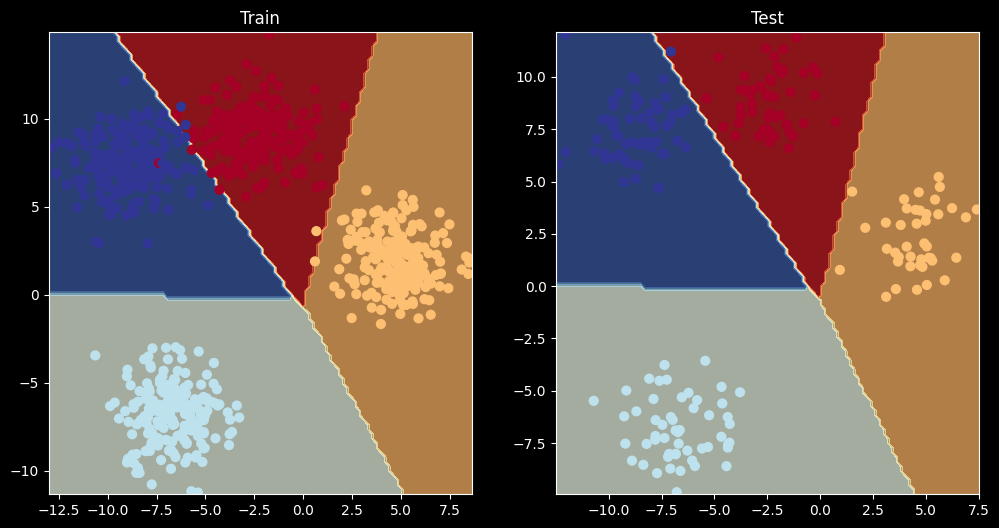

In [72]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics...

In [73]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.9 MB/s eta 0:00:00a 0:00:01


In [77]:
from torchmetrics import Accuracy

torchmetirc_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)
torchmetirc_accuracy(y_preds, y_blob_test)

tensor(0.9950)